# Mini Projet – Contrôle qualité composants PCB

**Dataset 2** 

On applique ici les mêmes analyses que sur le dataset 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

df = pd.read_excel('pcb_dataset_2.xlsx')
for col in ['component_type','production_line','supplier','defect','defect_type']:
    df[col] = df[col].astype('category')

var_quant = ['resistance_ohm','capacitance_uF','temperature_test_C',
             'voltage_drop_V','current_leak_mA','signal_noise_dB',
             'power_consumption_W','response_time_ms']

print(f"Dimensions : {df.shape[0]} observations, {df.shape[1]} variables")
print(f"Taux de défauts : {(df['defect']=='FAIL').mean()*100:.1f}%")
print(df[var_quant].describe().round(2))

Dimensions : 15000 observations, 14 variables
Taux de défauts : 37.7%
       resistance_ohm  capacitance_uF  temperature_test_C  voltage_drop_V  \
count        14983.00        15000.00            15000.00        15000.00   
mean           411.46           70.23               45.01            3.51   
std            449.73          103.79                2.97            0.26   
min              2.55            0.20               33.98            2.88   
25%              5.84            0.57               43.04            3.31   
50%            190.66            8.26               45.01            3.44   
75%            896.98          173.95               47.02            3.71   
max           1827.20          465.59               56.58            4.42   

       current_leak_mA  signal_noise_dB  power_consumption_W  response_time_ms  
count         15000.00         14998.00             15000.00          14999.00  
mean              0.36            16.61                 1.11              

Le dataset 2 contient aussi 15 000 composants et les mêmes variables que le dataset 1. Le taux de défauts est de **37.7 %** (contre 48.1 % dans le dataset 1), les classes sont donc un peu moins équilibrées ici.

In [2]:
print("\nValeurs manquantes :")
print(df.isnull().sum())


Valeurs manquantes :
component_id              0
component_type            0
production_line           0
supplier                  0
resistance_ohm           17
capacitance_uF            0
temperature_test_C        0
voltage_drop_V            0
current_leak_mA           0
signal_noise_dB           2
power_consumption_W       0
response_time_ms          1
defect                    0
defect_type            9348
dtype: int64


Contrairement au dataset 1, on a quelques valeurs manquantes, 17 pour `resistance_ohm`, 2 pour `signal_noise_dB` et 1 pour `response_time_ms`. C'est très peu (0.2 %)

## Distribution des variables qualitatives

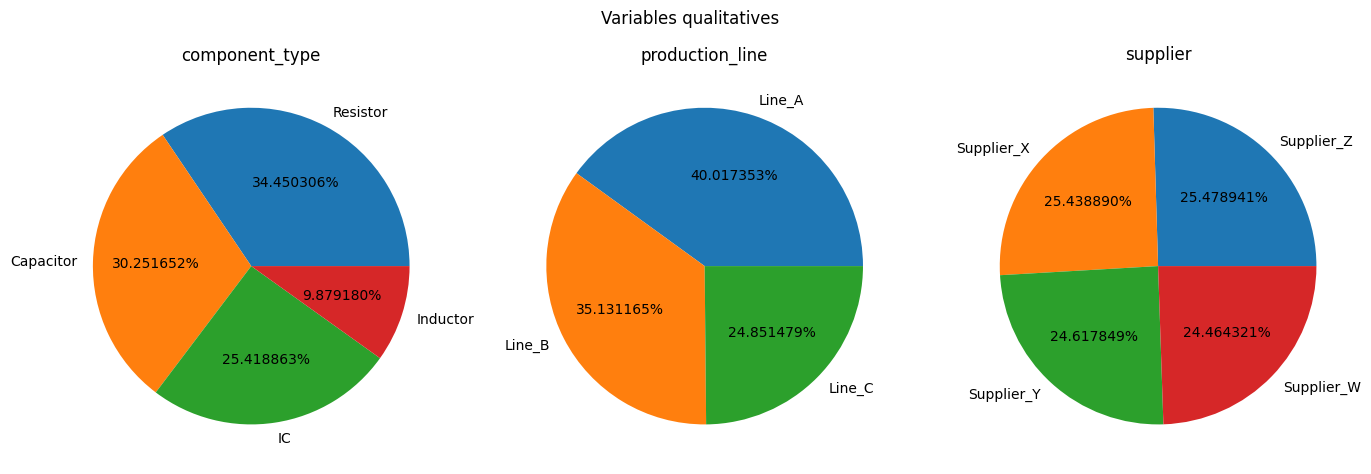

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['component_type', 'production_line', 'supplier']):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1f%%')
    ax.set_title(col)
plt.suptitle("Variables qualitatives")
plt.tight_layout()
plt.show()

Les fournisseurs sont bien équilibrés (25% chacun). Les lignes de production sont un peu moins équilibrées que dans le dataset 1,Line_A domine avec 40 %. Les Inductors sont sous-représentés par rapport aux autres types de composants

## 1. Analyse univariée par statut (OK / FAIL)

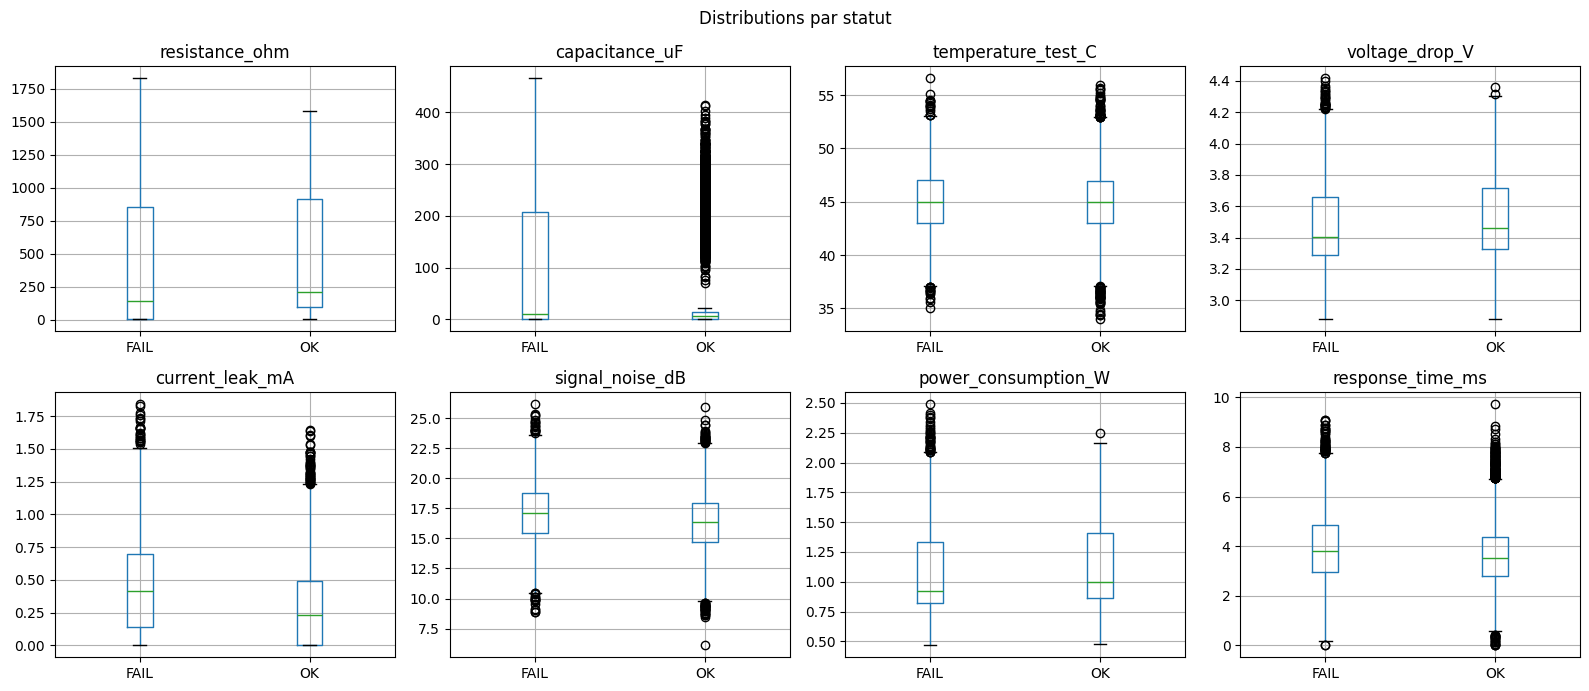

        resistance_ohm  capacitance_uF  temperature_test_C  voltage_drop_V  \
defect                                                                       
FAIL        361.511209       96.025053           45.044412        3.482722   
OK          441.683870       54.748108           44.995912        3.520446   

        current_leak_mA  signal_noise_dB  power_consumption_W  \
defect                                                          
FAIL           0.452821        17.098869             1.079807   
OK             0.296886        16.315200             1.126131   

        response_time_ms  
defect                    
FAIL            3.976784  
OK              3.632119  


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), var_quant):
    df.boxplot(column=col, by='defect', ax=ax)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle("Distributions par statut")
plt.tight_layout(); plt.show()

print(df.groupby('defect')[var_quant].mean())

Comme pour le dataset 1, `current_leak_mA` et `signal_noise_dB` montrent les différences les plus nettes entre OK et FAIL. On remarque aussi que `capacitance_uF` est en moyenne plus élevée pour les FAIL (96 vs 55 µF), ce qui était déjà le cas dans le dataset 1 mais semble plus marqué ici.

**Conclusion :** Le courant de fuite et le bruit restent les meilleurs indicateurs de défaut, ce qui confirme le dataset 1.

## 2. Matrice de corrélations

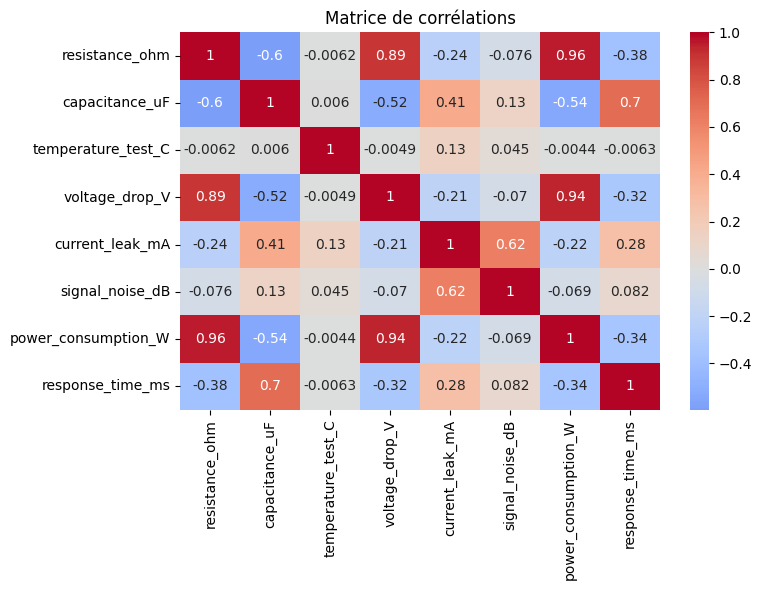

In [11]:
C = df[var_quant].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(C, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de corrélations")
plt.tight_layout(); plt.show()

La structure de corrélation est très similaire au dataset 1 :
`resistance_ohm`, `voltage_drop_V` et `power_consumption_W` restent fortement corrélées 0.89
`capacitance_uF` et `response_time_ms` corrélées positivement (r ≈ 0.70).
`temperature_test_C` est toujours indépendante des autres variables.

**Conclusion :** Le changement de capteurs n'a pas modifié les relations entre variables. La structure physique des données est robuste.

## 3. ACP centrée-réduite

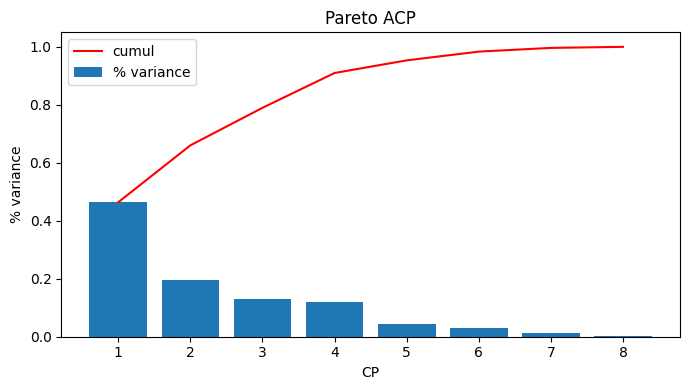

% variance : [46.3933653  19.62019035 12.9528076  12.00853229  4.35549415  3.01873602
  1.2809008   0.36997349]
Cumul      : [ 46.3933653   66.01355565  78.96636325  90.97489555  95.3303897
  98.34912571  99.63002651 100.        ]


In [5]:
X_cr = (df[var_quant] - df[var_quant].mean()) / df[var_quant].std()
acp  = PCA()
Xacp = acp.fit_transform(X_cr)
pq   = len(var_quant)

# Pareto
plt.figure(figsize=(7, 4))
plt.bar(range(1, pq+1), acp.explained_variance_ratio_, label='% variance')
plt.plot(range(1, pq+1), np.cumsum(acp.explained_variance_ratio_), color='red', label='cumul')
plt.xlabel("CP");
plt.ylabel("% variance")
plt.title("Pareto ACP");
plt.legend()
plt.tight_layout();
plt.show()
print("% variance :", (acp.explained_variance_ratio_*100))
print("Cumul      :", (np.cumsum(acp.explained_variance_ratio_)*100))

CP1 explique **46.4 %** de la variance et CP2 **19.6 %**, soit 66 % cumulé pour les 2 premiers axes . Il faut 4 axes pour dépasser 90 %. La répartition de la variance est quasiment identique au dataset 1.

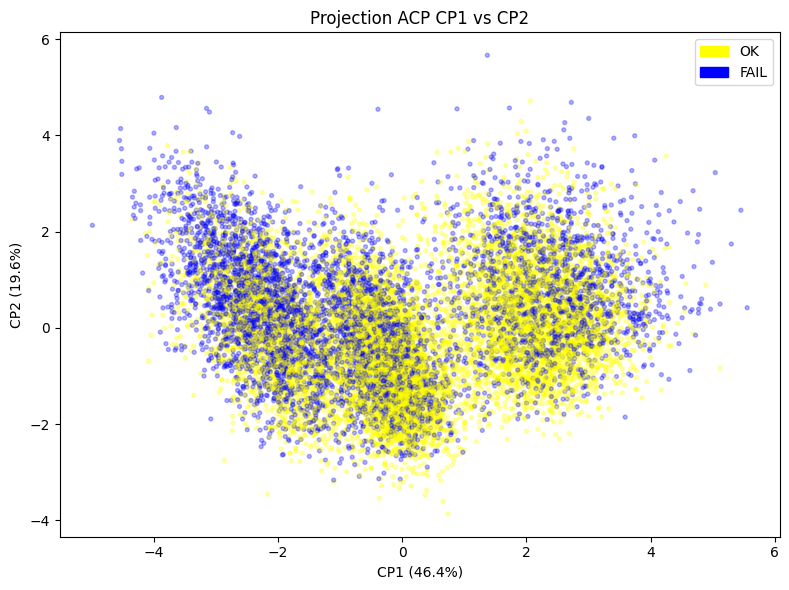

In [ ]:
# Projection CP1/CP2 colorée OK/FAIL
colors = df['defect'].map({'OK':'yellow','FAIL':'blue'})
plt.figure(figsize=(8, 6))
plt.scatter(Xacp[:,0], Xacp[:,1], c=colors, alpha=0.3)
plt.xlabel(f"CP1 ({acp.explained_variance_ratio_[0]*100}%)")
plt.ylabel(f"CP2 ({acp.explained_variance_ratio_[1]*100}%)")
plt.title("Projection ACP CP1 vs CP2")
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='yellow',label='OK'), Patch(color='blue',label='FAIL')])
plt.tight_layout(); plt.show()

Comme pour le dataset 1, les points OK et FAIL se chevauchent sur la projection ACP. L'ACP ne sépare pas les classes car elle maximise la variance totale et non la séparation inter-groupes.

In [ ]:
# Cercle des corrélations ACP
corr_cp = np.array([[np.corrcoef(Xacp[:,i], df[var_quant].iloc[:,j])[0,1]
                     for j in range(pq)] for i in range(pq)])

fig, ax = plt.subplots(figsize=(10,10))
ax.add_patch(plt.Circle((0,0), 1, fill=False, color='blue'))
ax.axhline(0);
ax.axvline(0)
for j, v in enumerate(var_quant):
    ax.scatter(corr_cp[0,j], corr_cp[1,j], color='orange')
    ax.text(corr_cp[0,j], corr_cp[1,j], v, fontsize=8)
ax.set_xlim(-1.2,1.2); 
ax.set_ylim(-1.2,1.2)
ax.set_xlabel(f"CP1 ({acp.explained_variance_ratio_[0]*100}%)")
ax.set_ylabel(f"CP2 ({acp.explained_variance_ratio_[1]*100}%)")
ax.set_title("Cercle des corrélations ACP")
plt.tight_layout();
plt.show()

Le cercle des corrélations reproduit le même schéma que le dataset 1 :
- **CP1** : résistance (0.92), puissance (0.91), tension (0.89) d'un côté, capacitance (−0.79) et temps de réponse (−0.61) de l'autre.
- **CP2** : dominée par `signal_noise_dB` (0.81) et `current_leak_mA` (0.77).

**Conclusion :** La structure factorielle est stable entre les deux campagnes de mesure.

## 4. ADL – OK vs FAIL

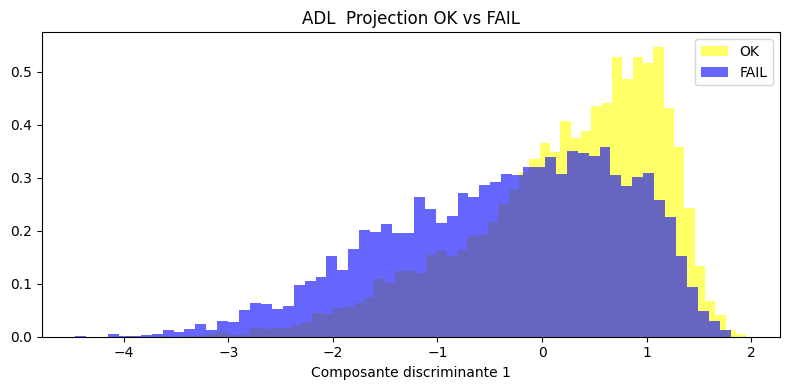

Corrélations avec CD1 :
  current_leak_mA : -0.8704742024207388
  capacitance_uF : -0.7345920088985963
  signal_noise_dB : -0.590018321775478
  response_time_ms : -0.4829183342244848
  resistance_ohm : 0.3292860929499828
  voltage_drop_V : 0.2688372990294841
  power_consumption_W : 0.24966248440244684
  temperature_test_C : -0.030137225903458312


In [8]:
lda  = LinearDiscriminantAnalysis()
Xlda = lda.fit_transform(df[var_quant], df['defect'])

# Distribution sur l'axe discriminant
fig, ax = plt.subplots(figsize=(8, 4))
for status, color in [('OK','yellow'), ('FAIL','blue')]:
    idx = df['defect'] == status
    ax.hist(Xlda[idx,0], bins=60, alpha=0.6, color=color, label=status, density=True)
ax.set_xlabel("Composante discriminante 1")
ax.set_title("ADL  Projection OK vs FAIL")
ax.legend(); plt.tight_layout(); plt.show()

# Corrélations variables / axe discriminant
corr_lda = {v: np.corrcoef(df[v].values, Xlda[:,0])[0,1] for v in var_quant}
print("Corrélations avec CD1 :")
for v, r in sorted(corr_lda.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {v} : {r}")

L'ADL sépare bien OK et FAIL sur un seul axe discriminant. Les variables les plus discriminantes sont :
- `current_leak_mA` 
- `capacitance_uF`  plus importante ici que dans le dataset 1
- `signal_noise_dB` significatif mais moins dominant que dans le dataset 1 

**Conclusion :** Le courant de fuite reste le critère n°1. Les capteurs du dataset 2 semblent capter un signal de discrimination supplémentaire via la capacitance, tandis que le bruit est un peu moins discriminant. Le diagnostic global reste le même.

## 5. ADL – Par type de défaut

Effectifs : defect_type
Solder_Issue     4951
Short_Circuit     680
Open_Circuit        9
Name: count, dtype: int64
Variance expliquée : [98.13426864  1.86573136] %


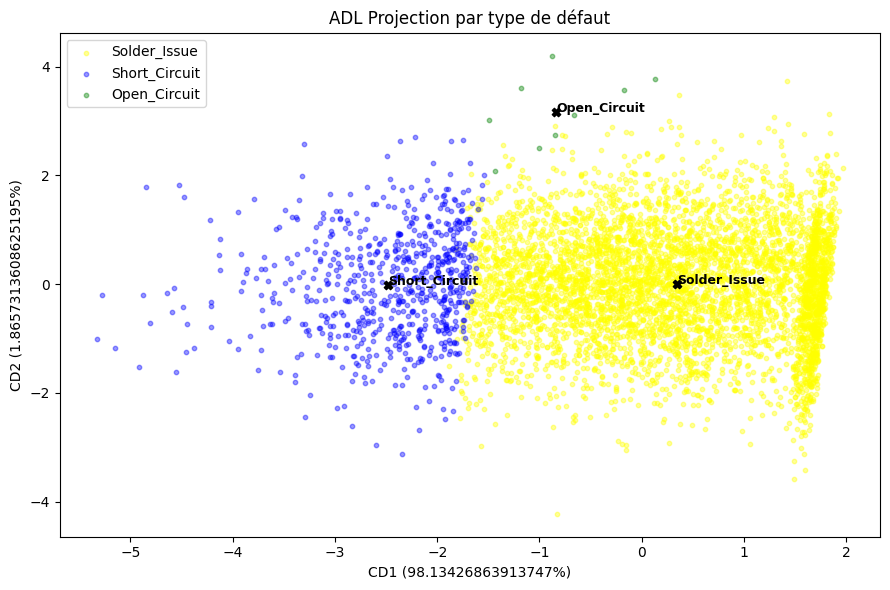

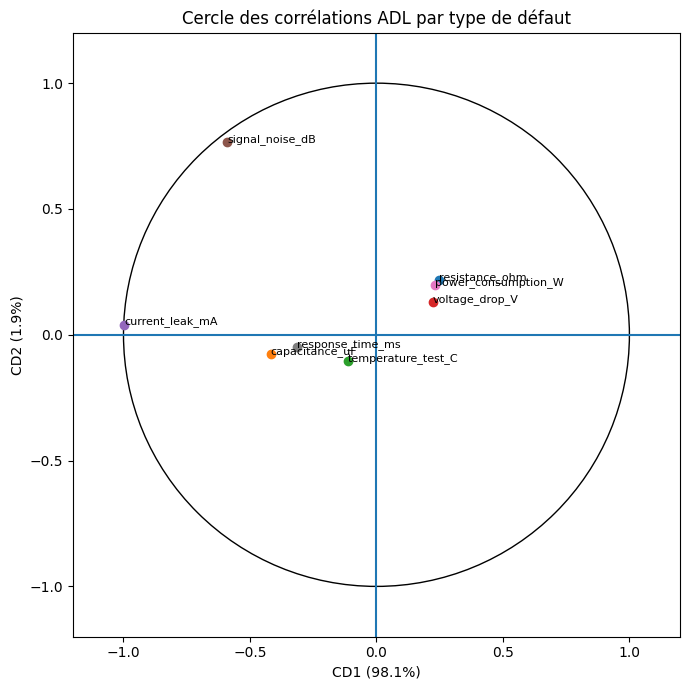

                          CD1       CD2
resistance_ohm       0.248535  0.217750
capacitance_uF      -0.418346 -0.076492
temperature_test_C  -0.112547 -0.102714
voltage_drop_V       0.222653  0.129249
current_leak_mA     -0.998141  0.040808
signal_noise_dB     -0.590172  0.767526
power_consumption_W  0.231236  0.197365
response_time_ms    -0.315684 -0.048144


In [10]:
df_fail = df[df['defect']=='FAIL'].dropna(subset=['defect_type']).copy()
print("Effectifs :", df_fail['defect_type'].value_counts())

lda2  = LinearDiscriminantAnalysis()
Xlda2 = lda2.fit_transform(df_fail[var_quant], df_fail['defect_type'])
print("Variance expliquée :", (lda2.explained_variance_ratio_*100), "%")

palette = {'Solder_Issue':'yellow','Short_Circuit':'blue','Open_Circuit':'green'}
plt.figure(figsize=(9, 6))
for dt, color in palette.items():
    idx = df_fail['defect_type'] == dt
    plt.scatter(Xlda2[idx,0], Xlda2[idx,1], c=color, alpha=0.4, s=10, label=dt)

centres     = df_fail.groupby('defect_type')[var_quant].mean()
centres_lda = lda2.transform(centres)
for i, dt in enumerate(centres.index):
    plt.scatter(centres_lda[i,0], centres_lda[i,1], c='black', marker='X', zorder=5)
    plt.text(centres_lda[i,0], centres_lda[i,1], dt, fontsize=9, fontweight='bold')
plt.xlabel(f"CD1 ({lda2.explained_variance_ratio_[0]*100}%)")
plt.ylabel(f"CD2 ({lda2.explained_variance_ratio_[1]*100}%)")
plt.title("ADL Projection par type de défaut")
plt.legend(); plt.tight_layout(); plt.show()

# Cercle des corrélations
corr2 = pd.DataFrame(
    {f"CD{i+1}": [np.corrcoef(df_fail[v].values, Xlda2[:,i])[0,1] for v in var_quant]
     for i in range(2)}, index=var_quant)

fig, ax = plt.subplots(figsize=(7, 7))
ax.add_patch(plt.Circle((0,0),1,fill=False))
ax.axhline(0)
ax.axvline(0)
for v in var_quant:
    ax.scatter(corr2.loc[v,'CD1'], corr2.loc[v,'CD2'])
    ax.text(corr2.loc[v,'CD1'], corr2.loc[v,'CD2'], v, fontsize=8)
ax.set_xlim(-1.2,1.2);
ax.set_ylim(-1.2,1.2)
ax.set_xlabel(f"CD1 ({lda2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"CD2 ({lda2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Cercle des corrélations ADL par type de défaut")
plt.tight_layout();
plt.show()
print(corr2)

La répartition des défauts est très différente du dataset 1 : les Solder_Issue dominent largement (4 951 contre 680 Short_Circuit et seulement 9 Open_Circuit).

L'ADL donne 2 axes discriminants (3 classes → k−1 = 2). Le premier axe CD1 concentre **98.1 %** du pouvoir discriminant, porté quasi-exclusivement par `current_leak_mA` (r = −0.998), exactement comme dans le dataset 1. Le second axe (1.9 %) est lié à `signal_noise_dB` (r = 0.77).

Les Open_Circuit sont trop rares (9 observations) pour être analysés de façon fiable.

**Conclusion :** La distinction entre Solder_Issue et Short_Circuit repose principalement sur le courant de fuite, confirmant le résultat du dataset 1.

---
## Conclusion générale – Dataset 2 et comparaison avec le Dataset 1

L'analyse du dataset 2 (capteurs différents) confirme les résultats du dataset 1 :

1. **Variables discriminantes stables :** Le courant de fuite (`current_leak_mA`) reste la variable la plus discriminante pour détecter les défauts et distinguer leur type. Le rapport signal/bruit (`signal_noise_dB`) est le second indicateur.

2. **Structure des données identique :** Les corrélations entre variables, les résultats de l'ACP et le cercle des corrélations sont quasiment identiques entre les deux campagnes de mesure. Le changement de capteurs n'a pas altéré la structure des données.

3. **Différences mineures :** Le taux de défauts est plus bas (37.7 % vs 48.1 %), la répartition des types de défauts est différente (beaucoup plus de Solder_Issue et très peu d'Open_Circuit), et la capacitance joue un rôle un peu plus important dans la discrimination OK/FAIL.

4. **Recommandation confirmée :** Un contrôle basé sur le courant de fuite et le bruit est robuste et ne dépend pas des appareils de mesure utilisés. C'est un résultat fort pour la mise en place d'un protocole de contrôle qualité industriel.